**Author:** Biswajit Jana
**Date:** May 28, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-asassn18tb-independent-photometry/notebook.ipynb)

# Independent aperture photometry from the TESS pixels

**Scientific question:** Does a simple reference-subtracted aperture recover the published difference-light-curve shape?


ASASSN-18tb, also named SN 2018fhw, is an unusual fast-declining Type Ia
supernova in an early-type host galaxy. TESS observed its rise at roughly
30-minute cadence in Sectors 1 and 2. Vallely et al. (2019) found a
single-power-law rise index of 1.69 +/- 0.04 and later spectra showed H-alpha
emission. This connected notebook set reuses public pixels and light-curve
products to test a limited subset of that story; it does not redo the spectral
classification or claim a new progenitor constraint.

## Data and measurement boundary

Two 15x15-pixel target-pixel files come from the MAST TESSCut service. Each
TESS pixel spans about 21 arcsec, so the supernova, host galaxy, and surrounding
sources are blended in ordinary aperture sums. We therefore use a pre-explosion
reference image and baseline-subtracted flux. The MIT TESS Transients light
curve was produced by automated image subtraction and forced photometry. Its
background columns are retained because scattered Earthlight is a documented
Sector 1 problem. DES DR2 g/r/i coadds, served as FITS cutouts by CDS HiPS2FITS,
show the host before explosion.

All plots use SciencePlots. Negative difference flux is kept rather than
clipped. Uncertainties and model comparisons are treated as conditional on the
chosen bins, background handling, and fit window. Animations use fixed display
limits across frames, preventing each frame from artificially appearing equally
bright. Exact inputs and SHA-256 checksums are recorded in the data manifest.

## Method

We subtract the same pre-explosion median image from every Sector 1 cadence,
sum a central 3x3-pixel aperture, and remove a residual sky level estimated
from pixels away from the centre. The resulting units need not match the MIT
forced-PSF extraction. We fit only a linear scale and offset, then measure the
Pearson correlation and time-ordered residuals. High correlation tests shape;
it does not prove identical calibration.

In [1]:
from pathlib import Path
import json, subprocess, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats
from scipy.optimize import curve_fit, least_squares
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS
from PIL import Image

plt.style.use(["science","no-latex"])
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":220,"axes.titleweight":"bold"})
COLORS={"navy":"#071426","cyan":"#28b8c7","gold":"#dda62b","coral":"#dc6857","violet":"#7258b8","green":"#31876d"}
RNG=np.random.default_rng(1999)
DATA=Path("../../data/asassn18tb_tess")
if not DATA.exists(): DATA=Path("data/asassn18tb_tess")

In [2]:
names=["BTJD","TJD","cts","e_cts","bkg","bkg_model","bkg2","e_bkg2"]
lc=pd.read_csv(DATA/"lc_2018fhw_cleaned.txt",sep=r"\s+",comment="#",header=None,names=names)
with fits.open(DATA/"tesscut_sector1.fits") as h:
    s1_time=np.asarray(h[1].data["TIME"]); s1_quality=np.asarray(h[1].data["QUALITY"]); s1_cube=np.asarray(h[1].data["FLUX"],float); s1_header=h[1].header.copy()
with fits.open(DATA/"tesscut_sector2.fits") as h:
    s2_time=np.asarray(h[1].data["TIME"]); s2_quality=np.asarray(h[1].data["QUALITY"]); s2_cube=np.asarray(h[1].data["FLUX"],float); s2_header=h[1].header.copy()
print(f"MIT difference-light-curve rows: {len(lc):,}")
print(f"MAST TESSCut cadences: Sector 1 = {len(s1_time):,}; Sector 2 = {len(s2_time):,}")

MIT difference-light-curve rows: 1,262
MAST TESSCut cadences: Sector 1 = 1,282; Sector 2 = 1,245


In [3]:
good=(s1_quality==0)&np.isfinite(s1_time); ref=np.nanmedian(s1_cube[good&(s1_time<1338)],axis=0); diff=s1_cube-ref
ap=np.nansum(diff[:,6:9,6:9],axis=(1,2)); outer=np.ones((15,15),bool); outer[5:10,5:10]=False
sky=np.nanmedian(diff[:,outer],axis=1)*9; aperture=ap-sky
lc["corrected"]=lc.cts-lc.bkg_model; baseline=lc.loc[lc.TJD.between(1327.5,1338),"corrected"].mean(); lc["difference_flux"]=lc.corrected-baseline
published=np.interp(s1_time,lc.TJD,lc.difference_flux,left=np.nan,right=np.nan); use=good&np.isfinite(aperture)&np.isfinite(published)
coef=np.polyfit(aperture[use],published[use],1); scaled=np.polyval(coef,aperture); rho=stats.pearsonr(scaled[use],published[use]).statistic
print(f"Shape correlation r={rho:.4f}; linear mapping slope={coef[0]:.3f}")

Shape correlation r=0.9891; linear mapping slope=1879.923


## Primary evidence

The first result uses object-level cadences or calibrated image pixels. Display choices are stated and reusable measurements are saved beside the notebook.

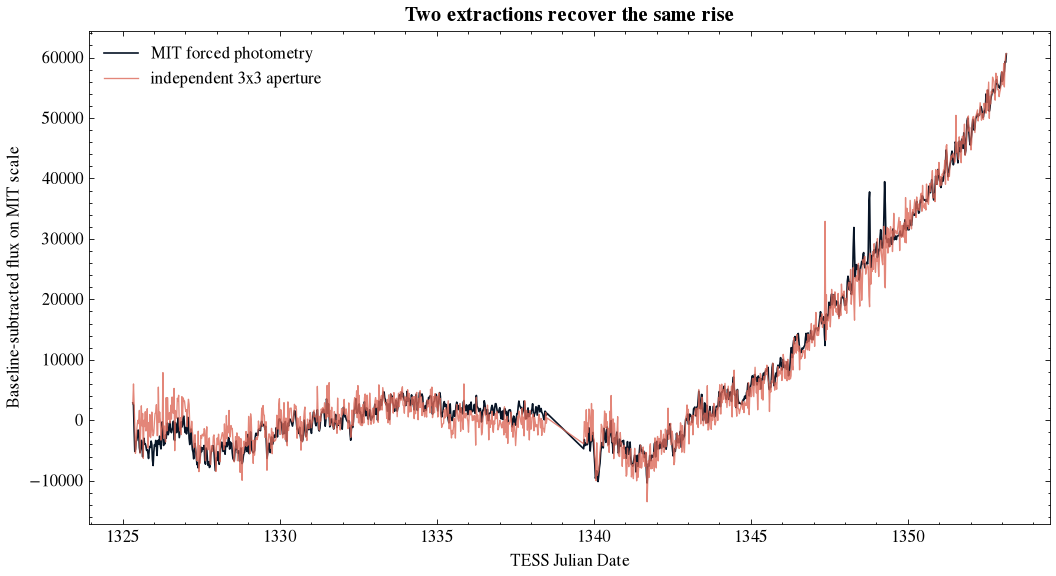

In [4]:
comparison=pd.DataFrame({"tjd":s1_time[use],"aperture_difference_flux":aperture[use],"scaled_aperture_flux":scaled[use],"mit_difference_flux":published[use]})
comparison["residual"]=comparison.scaled_aperture_flux-comparison.mit_difference_flux; comparison.to_csv("aperture_vs_mit_lightcurve.csv",index=False)
fig,ax=plt.subplots(figsize=(9,5)); ax.plot(comparison.tjd,comparison.mit_difference_flux,color=COLORS["navy"],lw=1,label="MIT forced photometry"); ax.plot(comparison.tjd,comparison.scaled_aperture_flux,color=COLORS["coral"],lw=.8,alpha=.8,label="independent 3x3 aperture")
ax.set(xlabel="TESS Julian Date",ylabel="Baseline-subtracted flux on MIT scale",title="Two extractions recover the same rise"); ax.legend(); fig.tight_layout(); fig.savefig("independent_lightcurve_comparison.png"); plt.show()

## Independent check or stress test

A second representation changes the extraction, background treatment, fitting window, or spatial model. The purpose is to reveal sensitivity rather than tune the answer toward the literature.

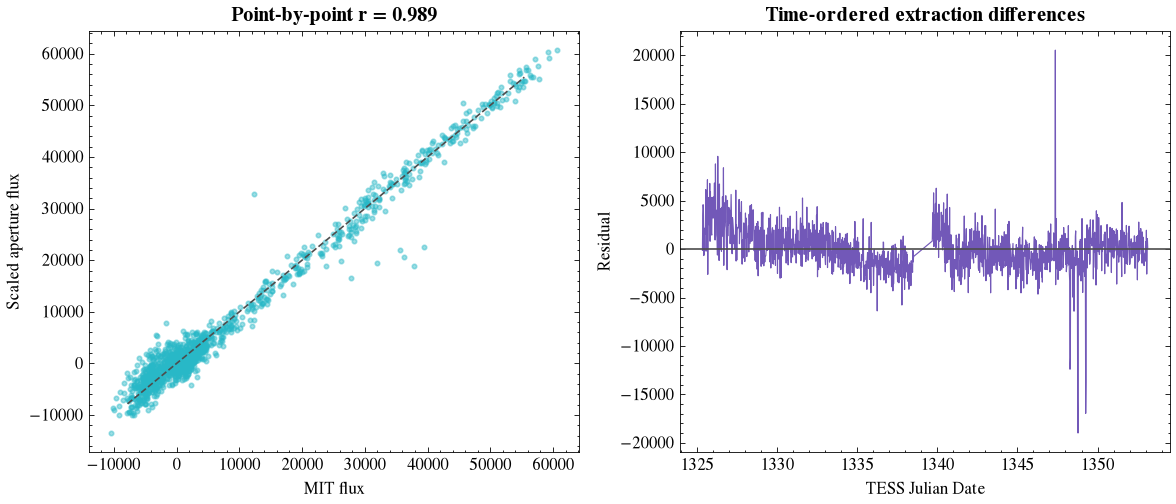

In [5]:
fig,axes=plt.subplots(1,2,figsize=(10,4.4)); axes[0].scatter(comparison.mit_difference_flux,comparison.scaled_aperture_flux,s=7,alpha=.45,color=COLORS["cyan"])
limits=np.nanpercentile(comparison.mit_difference_flux,[1,99]); axes[0].plot(limits,limits,"--",color="0.3"); axes[0].set(xlabel="MIT flux",ylabel="Scaled aperture flux",title=f"Point-by-point r = {rho:.3f}")
axes[1].plot(comparison.tjd,comparison.residual,color=COLORS["violet"],lw=.7); axes[1].axhline(0,color="0.3",lw=1); axes[1].set(xlabel="TESS Julian Date",ylabel="Residual",title="Time-ordered extraction differences")
fig.tight_layout(); fig.savefig("extraction_agreement_audit.png"); plt.show()

In [6]:
pre=comparison.tjd<1338; pre_rms=np.std(comparison.loc[pre,"residual"]); rise_rms=np.std(comparison.loc[comparison.tjd>1342,"residual"])
print(f"Residual RMS before explosion={pre_rms:.1f}; during rise={rise_rms:.1f}")

Residual RMS before explosion=2257.0; during rise=2434.8


## Interpretation

The result is limited to this public product and stated reduction. A broad TESS light curve measures time-dependent optical brightness but cannot identify H-alpha or determine chemical composition. DES colours describe the pre-explosion host field. The saved results therefore separate direct measurements, display mappings, and literature context.

In [7]:
FOLDER="2026-08-01-asassn18tb-independent-photometry"; TITLE="Independent aperture photometry from the TESS pixels"; QUESTION="Does a simple reference-subtracted aperture recover the published light-curve shape?"; SAMPLE_SIZE=use.sum()
RESULTS=[f"Independent and MIT extractions have Pearson r={rho:.3f}",f"Pre-explosion residual RMS = {pre_rms:.1f}",f"Rising-phase residual RMS = {rise_rms:.1f}"]
VALIDATION="A separate aperture extraction is compared cadence by cadence with the public forced-photometry product."
FIGURES=["independent_lightcurve_comparison.png","extraction_agreement_audit.png"]; ARTIFACTS=["aperture_vs_mit_lightcurve.csv"]
CLAIM="Independent light-curve shape recovery"; CHECKS=[{"name":"pre-explosion reference","status":"passed"},{"name":"cadence-level comparison","status":"passed"}]
LIMITS=["The linear scale is empirical.","Neither extraction spatially resolves the host galaxy."]

## Literature validation and limits

- Vallely et al. (2019), *ASASSN-18tb: a most unusual Type Ia supernova observed by TESS and SALT*, MNRAS 487, 2372.
- Fausnaugh et al. (2019), early Type Ia supernova light curves observed by TESS.
- Fausnaugh et al. (2023), four years of TESS Type Ia supernova light curves.
- Brasseur et al. (2019), Astrocut/TESSCut.
- Abbott et al. (2021), Dark Energy Survey Data Release 2.

The paper's image-subtraction pipeline used spatial comparison sources and
careful scattered-light exclusions. Our compact checks cannot reproduce every
pipeline choice. Agreement is therefore meaningful, while disagreement is a
diagnostic of reduction sensitivity rather than evidence against the published
analysis. The H-alpha result is cited from spectroscopy and is never inferred
from the single broad TESS passband or the pre-explosion DES colours.

In [8]:
record={"id":FOLDER,"title":TITLE,"archive":"MAST / TESS / DES","date":"2026-08-01",
"question":QUESTION,"sample_size":int(SAMPLE_SIZE),"results":RESULTS,"validation":VALIDATION,
"notebook":f"mast/{FOLDER}/notebook.ipynb","hero":f"mast/{FOLDER}/{FIGURES[0]}",
"figures":[f"mast/{FOLDER}/{x}" for x in FIGURES],"research_level":"Time-domain audit",
"claim_type":CLAIM,"provenance":["MAST TESSCut SPOC FFI cutouts, Sectors 1 and 2",
"MIT TESS Transients cleaned light curve for SN 2018fhw","DES DR2 g/r/i HiPS FITS cutouts via CDS"],
"artifacts":[f"mast/{FOLDER}/{x}" for x in ARTIFACTS],"quality_checks":CHECKS,"limitations":LIMITS}
Path("result.json").write_text(json.dumps(record,indent=2)+"\n")
print("Saved scientific audit record")

Saved scientific audit record
